<a href="https://colab.research.google.com/github/Dathu-03184/DL_Lab-Programs/blob/main/02%20program.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== Overfitting Example (Polynomial Regression) ===
Train MSE: 0.00389027085514378
Test MSE:  0.010724709996595161
Train R² : 0.9926296660629342
Test R²  : 0.9779133015852656


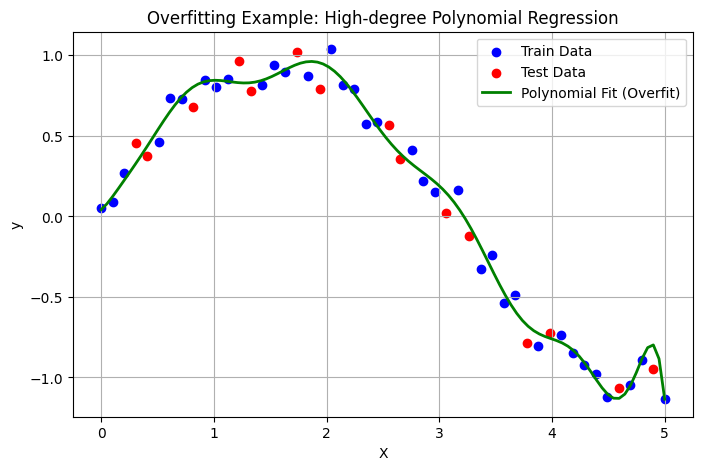

In [19]:
# 02 Program
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# -------------------------------
# 1️⃣ Generate synthetic data (non-linear)
# -------------------------------
np.random.seed(42)
X = np.linspace(0, 5, 50).reshape(-1, 1)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])  # sine wave + noise

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# -------------------------------
# 2️⃣ Fit a high-degree Polynomial Regression (Overfitting)
# -------------------------------
poly = PolynomialFeatures(degree=15)  # Very high degree → overfitting
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model = LinearRegression()
model.fit(X_train_poly, y_train)

y_train_pred = model.predict(X_train_poly)
y_test_pred = model.predict(X_test_poly)

# -------------------------------
# 3️⃣ Evaluate Overfitting
# -------------------------------
print("=== Overfitting Example (Polynomial Regression) ===")
print("Train MSE:", mean_squared_error(y_train, y_train_pred))
print("Test MSE: ", mean_squared_error(y_test, y_test_pred))
print("Train R² :", r2_score(y_train, y_train_pred))
print("Test R²  :", r2_score(y_test, y_test_pred))

# -------------------------------
# 4️⃣ Visualization
# -------------------------------
plt.figure(figsize=(8,5))
plt.scatter(X_train, y_train, color='blue', label='Train Data')
plt.scatter(X_test, y_test, color='red', label='Test Data')
plt.plot(np.linspace(0,5,100).reshape(-1,1),
         model.predict(poly.transform(np.linspace(0,5,100).reshape(-1,1))),
         color='green', linewidth=2, label='Polynomial Fit (Overfit)')
plt.title("Overfitting Example: High-degree Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
